In [1]:
import pandas as pd 
import numpy as np

In [2]:
data = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\Internship_project\Dataset\European_Bank.csv")
data.head(2)

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


In [3]:
print(data.columns)

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
data.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
## Find Churn Rate

churn_rate = data["Exited"].mean()
print("churn_rate",churn_rate)

churn_rate 0.2037


Exited = 1 → Customer left (Churned)
Exited = 0 → Customer stayed

In [7]:
data["Exited"].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

If churn rate:

10–20% → Normal imbalance

<10% → Highly imbalanced

50% → Balanced

Most bank churn datasets have 20% churn.

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

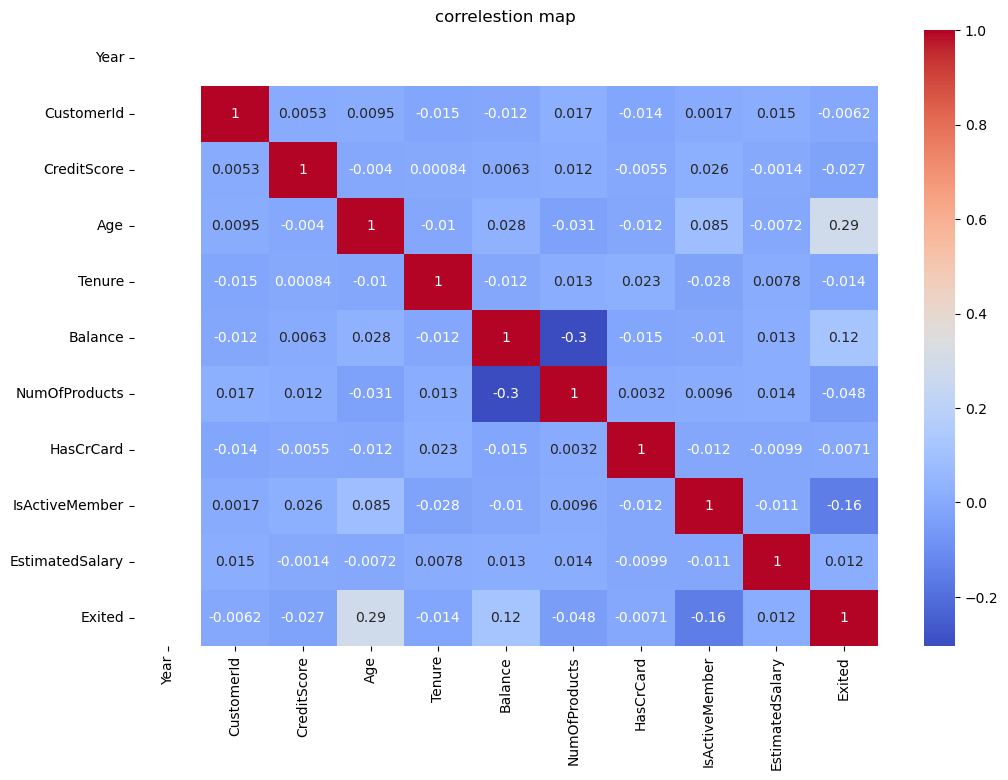

In [9]:
# Select only numeric columns

numeric_df = data.select_dtypes(include=[int,float])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(),annot=True, cmap='coolwarm')
plt.title("correlestion map")
plt.show()

In [10]:
data.groupby("IsActiveMember")["Exited"].mean()


IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

"Engagement is more important than financial strength."

Active customers:

1.Use services
2.Log in
3.Interact with bank

Inactive customers:

1.Weak relationship
2.High silent churn risk

In [11]:

data.groupby("NumOfProducts")["Exited"].mean()


NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

-> Customers with 2 products → Most loyal

Only 7.5% churn → Very stable group.

 -> Customers with 1 product → Risky

27% churn → Single-product customers are not deeply attached.

-> Customers with 3 or 4 products → Very strange

82% and 100% churn is unusual.

This usually happens because:

Very few customers have 3 or 4 products.

Small sample size makes churn rate unstable.

In [12]:
data['NumOfProducts'].value_counts()


NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

Create Engagement Profile

In [13]:
def segment_customer(row):
    if row["IsActiveMember"] == 1 and row['NumOfProducts'] >= 2:
        return "Highly Engaged"
    elif row["IsActiveMember"] == 1 and row['NumOfProducts'] == 1:
        return "Active low_product"
    elif row["IsActiveMember"] == 0 and row["Balance"] > 100000:
        return "High-Value Disengaged"
    else:
        return "Low Engagement"
    
data['EngagementSegment'] = data.apply(segment_customer,axis=1)

In [14]:
data.groupby('EngagementSegment')['Exited'].mean()

EngagementSegment
Active low_product       0.189231
High-Value Disengaged    0.327674
Highly Engaged           0.096600
Low Engagement           0.212595
Name: Exited, dtype: float64

In [15]:
data.groupby(["IsActiveMember", "NumOfProducts"])["Exited"].mean()


IsActiveMember  NumOfProducts
0               1                0.366521
                2                0.098881
                3                0.882353
                4                1.000000
1               1                0.189231
                2                0.055601
                3                0.752212
                4                1.000000
Name: Exited, dtype: float64

If:

Inactive + 2 products churn is still high →
Then engagement matters more than product depth.

If:

Inactive + 2 products churn is low →
Then financial dependency is stronger.

heare -> Then financial dependency is stronger.

In [16]:
def engagement_tier(row):
    if row['IsActiveMember'] == 1 and row['NumOfProducts'] >= 2:
        return "Highly Sticky"
    elif row['IsActiveMember'] == 1 and row['NumOfProducts'] == 1:
        return "Moderately Sticky"
    elif row['IsActiveMember'] == 0 and row['NumOfProducts'] >= 2:
        return "Financially Sticky"
    else:
        return "High Risk"

data['RetentionTier'] = data.apply(engagement_tier, axis=1)

data.groupby("RetentionTier")["Exited"].mean()


RetentionTier
Financially Sticky    0.162371
High Risk             0.366521
Highly Sticky         0.096600
Moderately Sticky     0.189231
Name: Exited, dtype: float64